170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


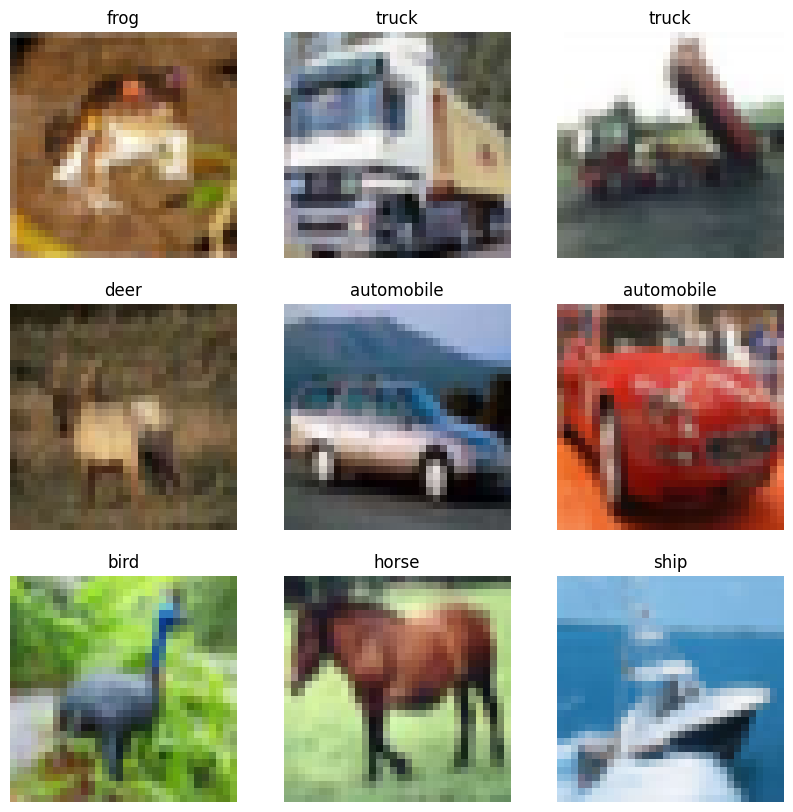

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Cargar CIFAR-10
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalizar los valores de píxeles (0-255 a 0-1)
x_train, x_test = x_train / 255.0, x_test / 255.0

# Etiquetas de clases
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Visualizar algunas imágenes
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.savefig('input_images.png')
plt.show()

# Convertir etiquetas a formato categórico
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

In [2]:
model = models.Sequential([
    # Primera capa convolucional
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2), strides=2),

    # Segunda capa convolucional
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    # Aplanamiento
    layers.Flatten(),

    # Capa densa
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # Bonus: Dropout para reducir overfitting
    layers.Dense(10, activation='softmax')  # Salida para 10 clases
])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 103s 128ms/step - accuracy: 0.3079 - loss: 1.8695 - val_accuracy: 0.5588 - val_loss: 1.2532
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 137s 123ms/step - accuracy: 0.5173 - loss: 1.3508 - val_accuracy: 0.6229 - val_loss: 1.0781
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 139s 119ms/step - accuracy: 0.5779 - loss: 1.1871 - val_accuracy: 0.6412 - val_loss: 1.0184
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 119ms/step - accuracy: 0.6157 - loss: 1.0914 - val_accuracy: 0.6647 - val_loss: 0.9557
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 93s 119ms/step - accuracy: 0.6397 - loss: 1.0187 - val_accuracy: 0.6833 - val_loss: 0.9115
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 138s 114ms/step - accuracy: 0.6612 - loss: 0.9715 - val_accuracy: 0.6930 - val_loss: 0.8857
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 88s 112ms/step - accuracy: 0.6807 - loss: 0.9080 - val_accuracy: 0.7015 - val_loss: 0.8671
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 143s 114ms/step - accuracy: 0.6894 - l

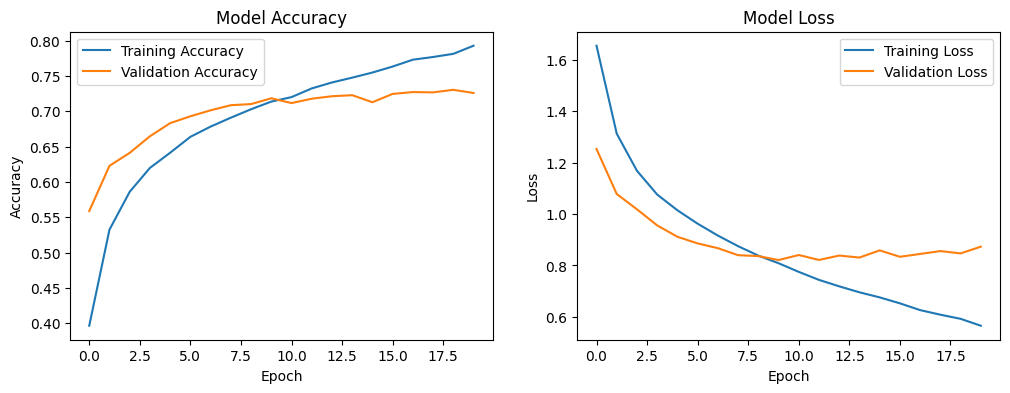

In [3]:
# Compilar el modelo
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entrenar el modelo
history = model.fit(x_train, y_train, epochs=20, batch_size=64,
                    validation_data=(x_test, y_test))

# Visualizar curvas de entrenamiento
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.savefig('training_curves.png')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7274 - loss: 0.8733
Test Accuracy: 0.7260
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


<Figure size 1000x1000 with 0 Axes>

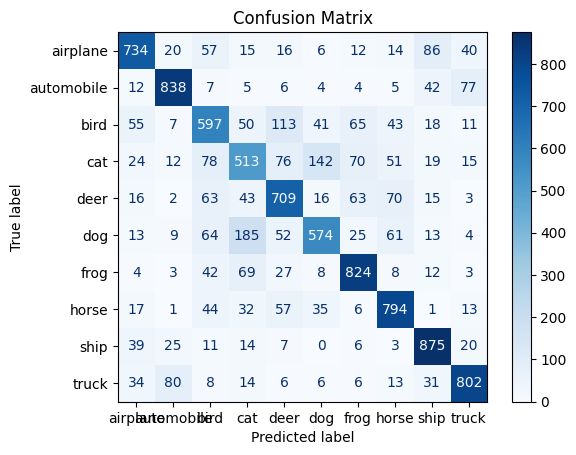

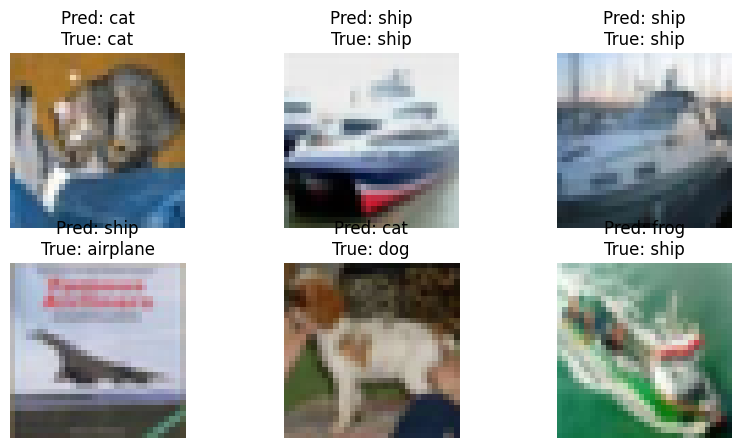

In [4]:
# Evaluar el modelo
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predicciones
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Matriz de confusión
cm = confusion_matrix(y_test_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(10, 10))
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

# Visualizar predicciones correctas e incorrectas
correct = np.where(y_pred_classes == y_test_classes)[0]
incorrect = np.where(y_pred_classes != y_test_classes)[0]

plt.figure(figsize=(10, 5))
for i, idx in enumerate(correct[:3]):
    plt.subplot(2, 3, i+1)
    plt.imshow(x_test[idx])
    plt.title(f"Pred: {class_names[y_pred_classes[idx]]}\nTrue: {class_names[y_test_classes[idx]]}")
    plt.axis('off')
for i, idx in enumerate(incorrect[:3]):
    plt.subplot(2, 3, i+4)
    plt.imshow(x_test[idx])
    plt.title(f"Pred: {class_names[y_pred_classes[idx]]}\nTrue: {class_names[y_test_classes[idx]]}")
    plt.axis('off')
plt.savefig('predictions.png')
plt.show()

In [5]:
# Guardar el modelo
model.save('cnn_cifar10.h5')

# Cargar el modelo
loaded_model = tf.keras.models.load_model('cnn_cifar10.h5')